In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import biweight_scale
from scipy.stats import median_abs_deviation

In [2]:
def robust_sigma(data):
    """
    Equivalent to IDL's robust_sigma - uses median absolute deviation
    scaled to approximate standard deviation for Gaussian distributions.
    """
    mad = median_abs_deviation(data, scale='normal')
    return mad

In [3]:
bootfile = 'boot.txt'

# Read in the data
    # Columns: ra_0, dec_0, ell, rhalf, theta, sigmaback, (7th column -- not loading currently)
data = np.loadtxt(bootfile)

ra_0 = data[:, 0]
dec_0 = data[:, 1]
ell = data[:, 2]
rhalf = data[:, 3]
theta = data[:, 4]
sigmaback = data[:, 5]


In [4]:
# Get the best fit value (first row)
ellbest = ell[0]
ra_0best = ra_0[0]
dec_0best = dec_0[0]
rhalf_best = rhalf[0]
theta_best = theta[0]
sigmaback_best = sigmaback[0]

In [5]:
# Filter out bad fits
goodindex = np.where((ell < 0.9) & (rhalf < 3.0) & (ell > 0.03))[0]
ell = ell[goodindex]
ra_0 = ra_0[goodindex]
dec_0 = dec_0[goodindex]
rhalf = rhalf[goodindex]
theta = theta[goodindex]
sigmaback = sigmaback[goodindex]

In [17]:
# Wrap theta into [-90, 90] range, will have to check this on a case-by-base basis.

step2 = np.where(theta < 0.0)[0]
theta[step2] = theta[step2] + 180.0
#stepneg = np.where(theta < -90.0)[0]
#theta[stepneg] = theta[stepneg] + 180.0

In [18]:
# 95% upper limit on ellipticity (using 68% as in the code comment/variable name)
ellsort = np.sort(ell)
onesigindex = int(0.95 * len(ellsort))
print(f"95% upper limit on ellipticity is: {ellsort[onesigindex]:.4f}")

95% upper limit on ellipticity is: 0.2938


In [19]:
# Convert ra_0 and dec_0 to arcmin offsets from best-fit position
x_0 = (ra_0 - ra_0best) * np.cos(dec_0 * np.pi / 180.0) * 60.0
y_0 = (dec_0 - dec_0best) * 60.0

In [20]:
# Compute robust sigmas (uncertainties)
ell_sig = robust_sigma(ell)
rhalf_sig = np.std(rhalf)  # Note: code overwrites robust_sigma with stddev
ra_0_sig = robust_sigma(ra_0)
dec_0_sig = robust_sigma(dec_0)
theta_sig = robust_sigma(theta)
sigmaback_sig = robust_sigma(sigmaback)
x_sig = robust_sigma(x_0) * 60.0  # in arcsec
y_sig = robust_sigma(y_0) * 60.0  # in arcsec

In [21]:
# Get medians
nsamps = len(rhalf)
upper_half = int(nsamps / 2.0 + 0.341 * nsamps)
lower_half = int(nsamps / 2.0 - 0.341 * nsamps)
    
ra_0med = np.median(ra_0)
dec_0med = np.median(dec_0)
x_0med = np.median(x_0)
y_0med = np.median(y_0)
    
rhalfmed = np.median(rhalf)
rhalfsort = np.sort(rhalf)
rhalf_upper = rhalfsort[upper_half]
rhalf_lower = rhalfsort[lower_half]
rhalf_uppererr = rhalf_upper - rhalfmed
rhalf_lowererr = rhalfmed - rhalf_lower
    
thetamed = np.median(theta)
backmed = np.median(sigmaback)
ellmed = np.median(ell)

In [22]:
# Print results
print(f"\nRhalf is: {rhalf_best:.2f}' +/- {rhalf_sig:.4f}'")
print(f"  Median Rhalf: {rhalfmed:.4f}' (+{rhalf_uppererr:.4f} / -{rhalf_lowererr:.4f})")
print(f"\nMedian ellipticity is: {ellmed:.4f}")
print(f"Ellipticity is: {ellbest:.2f} +/- {ell_sig:.2f}")
print(f"\nRA median is: {ra_0med}")
print(f"RA best value: {ra_0best} +/- {x_sig:.2f} arcsec")
print(f"\nDEC best value: {dec_0best} +/- {y_sig:.2f} arcsec")
print(f"\nPA: Best value = {theta_best:.2f} +/- {theta_sig:.4f} deg")
print(f"PA: Median = {thetamed:.2f} deg")
print(f"\nMedian RA, DEC: {ra_0med}, {dec_0med}")
print(f"Best RA, DEC: {ra_0best}, {dec_0best}")


Rhalf is: 0.37' +/- 0.0297'
  Median Rhalf: 0.3759' (+0.0344 / -0.0293)

Median ellipticity is: 0.1678
Ellipticity is: 0.13 +/- 0.07

RA median is: 358.31213
RA best value: 358.31208 +/- 1.34 arcsec

DEC best value: 22.102591 +/- 1.27 arcsec

PA: Best value = 98.57 +/- 18.5591 deg
PA: Median = 97.07 deg

Median RA, DEC: 358.31213, 22.1025725
Best RA, DEC: 358.31208, 22.102591


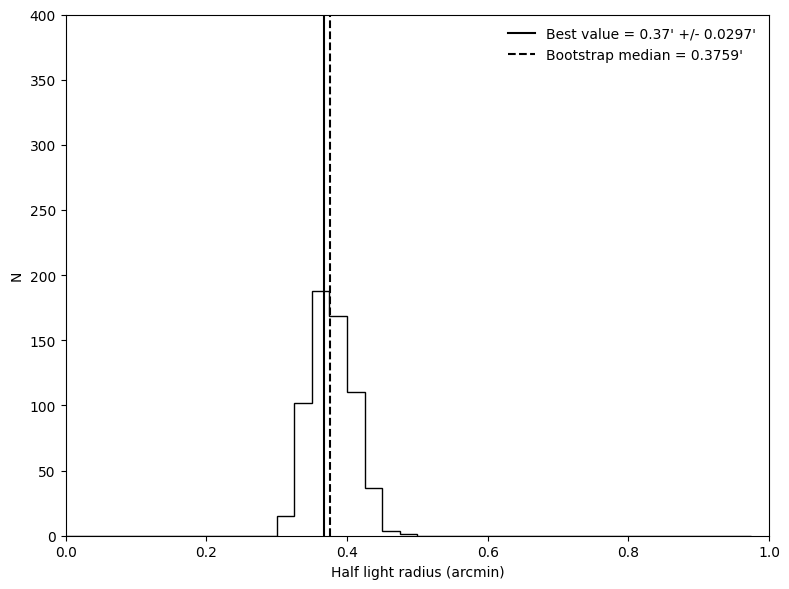

In [23]:
# --- Plotting ---
yline = [-10, 10000]
    
# Half-light radius histogram
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(rhalf, bins=np.arange(0, 1.0, 0.025), histtype='step', color='black')
ax.axvline(rhalf_best, color='black', linestyle='-', label=f"Best value = {rhalf_best:.2f}' +/- {rhalf_sig:.4f}'")
ax.axvline(rhalfmed, color='black', linestyle='--', label=f"Bootstrap median = {rhalfmed:.4f}'")
ax.set_xlabel("Half light radius (arcmin)")
ax.set_ylabel("N")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 400)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("rhalf_hist.png", dpi=150, bbox_inches='tight')
plt.show()
    

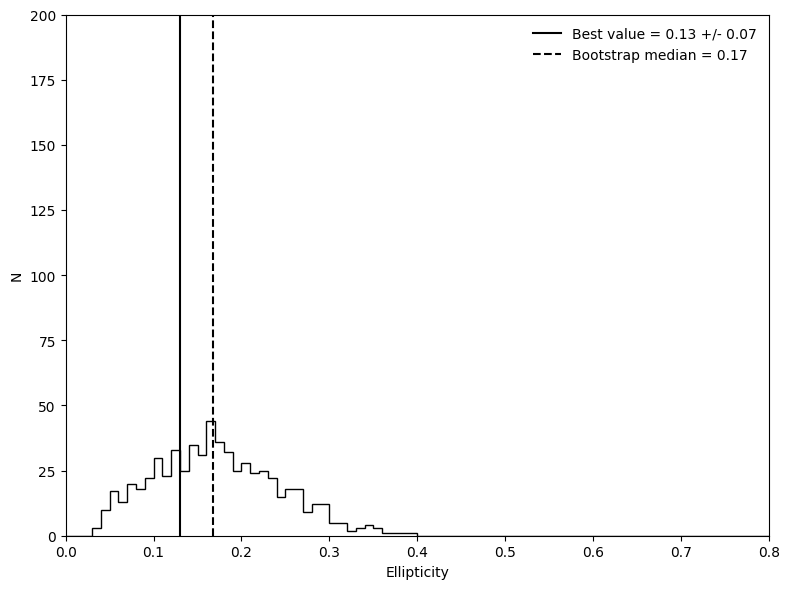

In [24]:
# Ellipticity histogram
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(ell, bins=np.arange(0, 1.0, 0.01), histtype='step', color='black')
ax.axvline(ellbest, color='black', linestyle='-', label=f"Best value = {ellbest:.2f} +/- {ell_sig:.2f}")
ax.axvline(ellmed, color='black', linestyle='--', label=f"Bootstrap median = {ellmed:.2f}")
ax.set_xlabel("Ellipticity")
ax.set_ylabel("N")
ax.set_xlim(0.0, 0.8)
ax.set_ylim(0, 200)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("ell_hist.png", dpi=150, bbox_inches='tight')

plt.show()

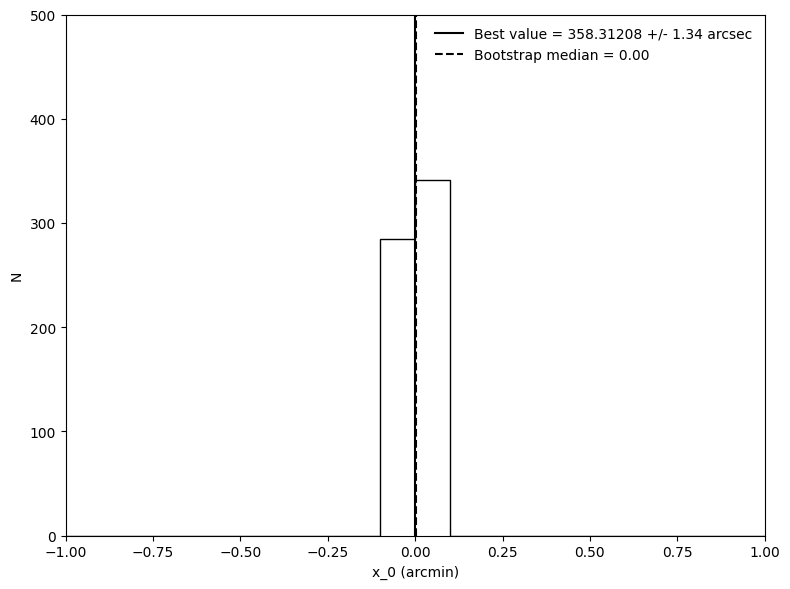

In [25]:
# x_0 histogram
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(x_0, bins=np.arange(-2.0, 2.0, 0.1), histtype='step', color='black')
ax.axvline(0.0, color='black', linestyle='-', label=f"Best value = {ra_0best} +/- {x_sig:.2f} arcsec")
ax.axvline(x_0med, color='black', linestyle='--', label=f"Bootstrap median = {x_0med:.2f}")
ax.set_xlabel("x_0 (arcmin)")
ax.set_ylabel("N")
ax.set_xlim(-1, 1)
ax.set_ylim(0, 500)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("RAoffset_hist.png", dpi=150, bbox_inches='tight')

plt.show()

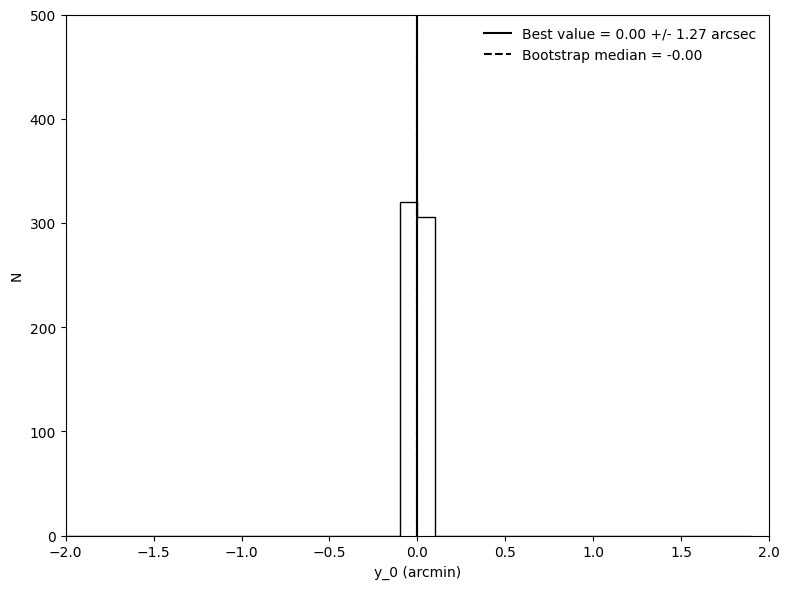

In [26]:
# y_0 histogram
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(y_0, bins=np.arange(-2.0, 2.0, 0.1), histtype='step', color='black')
ax.axvline(0.0, color='black', linestyle='-', label=f"Best value = 0.00 +/- {y_sig:.2f} arcsec")
ax.axvline(y_0med, color='black', linestyle='--', label=f"Bootstrap median = {y_0med:.2f}")
ax.set_xlabel("y_0 (arcmin)")
ax.set_ylabel("N")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(0, 500)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("DECoffset_hist.png", dpi=150, bbox_inches='tight')

plt.show()

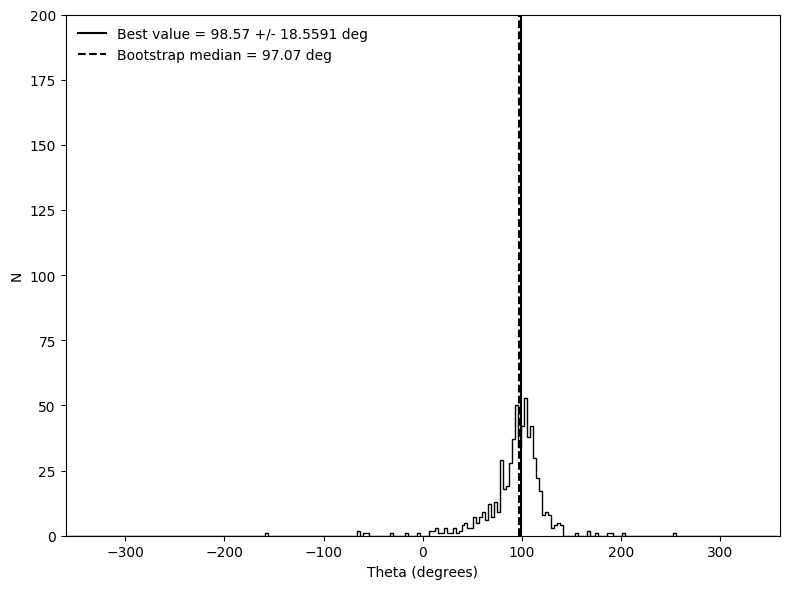

In [29]:
# Theta histogram
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(theta, bins=np.arange(-360, 360, 3.), histtype='step', color='black')
ax.axvline(theta_best, color='black', linestyle='-', label=f"Best value = {theta_best:.2f} +/- {theta_sig:.4f} deg")
ax.axvline(thetamed, color='black', linestyle='--', label=f"Bootstrap median = {thetamed:.2f} deg")
ax.set_xlabel("Theta (degrees)")
ax.set_ylabel("N")
ax.set_xlim(-360.0, 360.0)
ax.set_ylim(0, 200)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("theta_hist.png", dpi=150, bbox_inches='tight')

plt.show()